# 02 · สำรวจข้อมูล (Exploratory Data Analysis)

อ่านเฉพาะไฟล์ใน `data/raw/` ที่ได้จาก `01_data_collection.ipynb` (ไม่เรียก API)
เป้าหมายคือเข้าใจพฤติกรรมน้ำในลุ่มน้ำอู่ตะเภา แล้วเลือก feature และ target สำหรับโมเดลทำนาย

1. ความครบถ้วนและคุณภาพของข้อมูล
2. ภาพรวมระยะยาว: ระดับน้ำสูงสุดรายปี X.44
3. เจาะเหตุการณ์น้ำท่วม พ.ย. 2568
4. เวลาเดินทางของน้ำจากต้นน้ำถึงตัวเมือง
5. ฝนจาก 3 แหล่งเทียบกัน
6. ฝนสะสม ความชื้นในดิน และระดับน้ำ
7. GloFAS เทียบกับปริมาณน้ำที่วัดจริง
8. ฤดูกาลและ ENSO
9. แผนที่: สถานี ขอบเขตน้ำท่วมจริง และภูมิประเทศ
10. สรุปข้อค้นพบและ feature ที่จะใช้

In [1]:
import json

import folium
import matplotlib.pyplot as plt
import numpy
import pandas
import rioxarray
from IPython.display import display

from mojito import config

RAW = config.RAW_DIR
plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
EVENT_COLOR = "#d62728"

stations = pandas.read_parquet(RAW / "stations.parquet")
waterlevel = pandas.read_parquet(RAW / "waterlevel_tele.parquet")
rain_gauge = pandas.read_parquet(RAW / "rain_daily_gauge.parquet")
rid = pandas.read_parquet(RAW / "rid_daily.parquet")
annual_max = pandas.read_parquet(RAW / "x44_annual_max.parquet")
era5 = pandas.read_parquet(RAW / "era5_hourly.parquet")
glofas = pandas.read_parquet(RAW / "glofas_daily.parquet")
ghcnd = pandas.read_parquet(RAW / "ghcnd_daily.parquet")
oni = pandas.read_parquet(RAW / "oni.parquet")
gfm_index = pandas.read_parquet(RAW / "gfm_2025_index.parquet")

for frame in (rain_gauge, rid, glofas, ghcnd):
    frame["date"] = pandas.to_datetime(frame["date"])

# Source systems write 999999 / -999 for "no reading"; they are not water levels
SENTINEL = (waterlevel["waterlevel_msl"].abs() >= 999) | (waterlevel["discharge"].abs() >= 99999)
print("ค่า sentinel (999999 / -999) ต่อสถานี:")
print(waterlevel[SENTINEL].groupby("station_code").size().to_string())
waterlevel.loc[waterlevel["waterlevel_msl"].abs() >= 999, "waterlevel_msl"] = numpy.nan
waterlevel.loc[waterlevel["discharge"].abs() >= 99999, "discharge"] = numpy.nan

# Hourly series per station; HII stations log every 10 minutes
waterlevel_hourly = (
    waterlevel.set_index("timestamp")
    .groupby("station_code")[["waterlevel_msl", "discharge"]]
    .resample("h").mean()
)
level = waterlevel_hourly["waterlevel_msl"].unstack("station_code")
discharge = waterlevel_hourly["discharge"].unstack("station_code")

# ERA5: basin mean of the grid points and the point over the city
era5_basin = era5.groupby("timestamp")[["precipitation", "soil_moisture_0_to_7cm",
                                        "soil_moisture_7_to_28cm", "soil_moisture_28_to_100cm"]].mean()
era5_basin_daily = era5_basin.resample("D").agg({
    "precipitation": "sum", "soil_moisture_0_to_7cm": "mean",
    "soil_moisture_7_to_28cm": "mean", "soil_moisture_28_to_100cm": "mean",
})
era5_basin_daily.index = era5_basin_daily.index.tz_localize(None)

x44_info = stations[(stations["code"] == "X.44") & (stations["kind"] == "waterlevel")].iloc[0]
X44_BANK = 7.15  # ระดับตลิ่ง (RID)
X44_FLOOD = 7.40  # ระดับเริ่มท่วมพื้นที่ลุ่มต่ำ (ศูนย์อุทกวิทยาภาคใต้)
print("X.44 min_bank จาก ThaiWater:", x44_info["min_bank"], "| ground level:", x44_info["ground_level"])

ค่า sentinel (999999 / -999) ต่อสถานี:
station_code
ONE037        2
SLA002    15562


X.44 min_bank จาก ThaiWater: 7.15 | ground level: -2.204


## 1 · ความครบถ้วนและคุณภาพของข้อมูล
สีแสดง % ของชั่วโมงในเดือนนั้นที่มีข้อมูลระดับน้ำ ช่องว่างใหญ่จะกระทบการเทรนโมเดลอนุกรมเวลา

/tmp/ipykernel_74532/1204618065.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  coverage = level.notna().groupby(level.index.to_period("M")).mean().T * 100


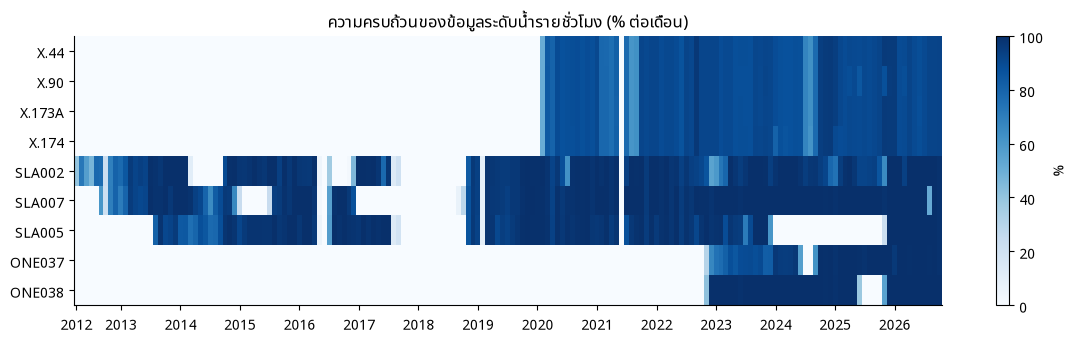

In [2]:
coverage = level.notna().groupby(level.index.to_period("M")).mean().T * 100
coverage = coverage.loc[[c for c in config.WATERLEVEL_STATIONS if c in coverage.index]]

fig, ax = plt.subplots(figsize=(14, 3.5))
image = ax.imshow(coverage.values, aspect="auto", cmap="Blues", vmin=0, vmax=100, interpolation="none")
years = coverage.columns.year
ticks = [i for i in range(len(years)) if i == 0 or years[i] != years[i - 1]]
ax.set_xticks(ticks, [str(years[i]) for i in ticks])
ax.set_yticks(range(len(coverage)), coverage.index)
ax.grid(False)
ax.set_title("ความครบถ้วนของข้อมูลระดับน้ำรายชั่วโมง (% ต่อเดือน)")
fig.colorbar(image, ax=ax, label="%")
plt.show()

In [3]:
quality = level.describe().T[["count", "min", "50%", "max"]]
quality["hourly_jump_gt_1m"] = (level.diff().abs() > 1).sum()
waterlevel_stations = stations[stations["kind"] == "waterlevel"].set_index("code")
quality["min_bank"] = quality.index.map(waterlevel_stations["min_bank"])
quality.round(2)

,count,min,50%,max,hourly_jump_gt_1m,min_bank
station_code,,,,,,
ONE037,30014.0,-0.32,0.22,2.81,0,0.84
ONE038,30249.0,-0.43,0.24,2.11,0,0.90
SLA002,97480.0,1.85,3.05,12.27,264,9.34
SLA005,81365.0,-5.71,0.29,7.68,414,0.97
SLA007,95646.0,-1.00,0.14,12.47,2,1.59
X.173A,50542.0,0.19,10.38,18.00,3,16.13
X.174,50433.0,0.00,4.41,24.02,8,8.88
X.44,50547.0,-0.31,0.51,9.97,0,7.15
X.90,50427.0,2.03,2.92,12.18,2,9.34


**ข้อสังเกต:** ค่า `min`/`max` ที่ห่างจากค่ากลางมากผิดปกติ และจำนวนครั้งที่ระดับน้ำกระโดดเกิน 1 ม. ภายใน 1 ชั่วโมง
บอกว่ามี spike/ค่าผิดพลาดของเซนเซอร์ ต้องกรองก่อนเทรน (เช่น rolling median หรือตัดค่าที่เปลี่ยนเร็วเกินกายภาพ)

## 2 · ภาพรวมระยะยาว: ระดับน้ำสูงสุดรายปี X.44 (2510–ปัจจุบัน)
X.44 อยู่กลางตัวเมืองหาดใหญ่ เป็นสถานีที่ใช้ตัดสินระดับเตือนภัยของเมือง

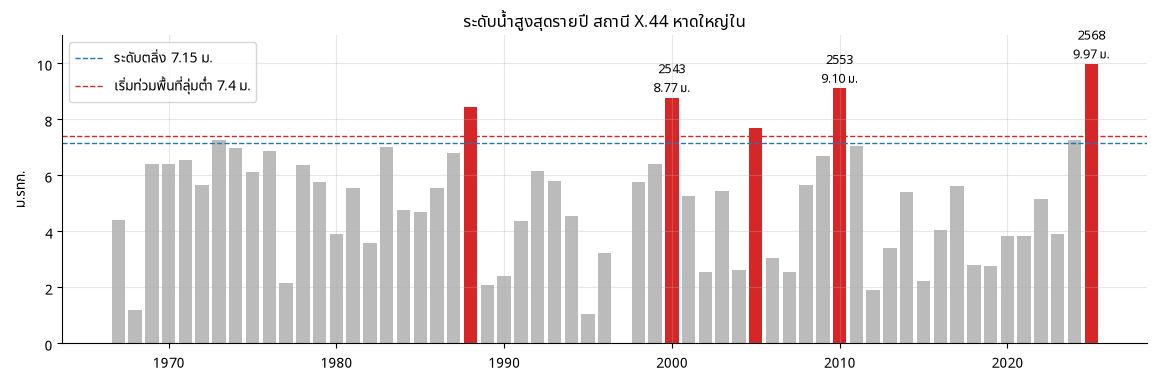

ปีที่ระดับน้ำสูงสุดเกิน 7.4 ม.: 5 จาก 58 ปี
ปี (ค.ศ.): 1988, 2000, 2005, 2010, 2025


In [4]:
annual = annual_max.dropna()
colors = ["#bbbbbb" if v < X44_FLOOD else EVENT_COLOR for v in annual["max_stage_msl"]]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(annual["water_year"], annual["max_stage_msl"], color=colors)
ax.axhline(X44_BANK, color="#1f77b4", ls="--", lw=1, label=f"ระดับตลิ่ง {X44_BANK} ม.")
ax.axhline(X44_FLOOD, color=EVENT_COLOR, ls="--", lw=1, label=f"เริ่มท่วมพื้นที่ลุ่มต่ำ {X44_FLOOD} ม.")
for year in (2000, 2010, 2025):
    value = annual.set_index("water_year").loc[year, "max_stage_msl"]
    ax.annotate(f"{year + 543}\n{value:.2f} ม.", (year, value), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("ม.รทก.")
ax.set_ylim(0, 11)
ax.set_title("ระดับน้ำสูงสุดรายปี สถานี X.44 หาดใหญ่ใน")
ax.legend(loc="upper left")
plt.show()

over = annual[annual["max_stage_msl"] >= X44_FLOOD]
print(f"ปีที่ระดับน้ำสูงสุดเกิน {X44_FLOOD} ม.: {len(over)} จาก {len(annual)} ปี")
print("ปี (ค.ศ.):", ", ".join(str(y) for y in over["water_year"]))

## 3 · เจาะเหตุการณ์น้ำท่วม พ.ย. 2568
ลำดับสถานีจากต้นน้ำลงสู่ทะเลสาบ: X.173A → X.90 / SLA002 → **X.44 (ตัวเมือง)** → SLA007 → ONE037 → SLA005 (ทะเลสาบสงขลา)

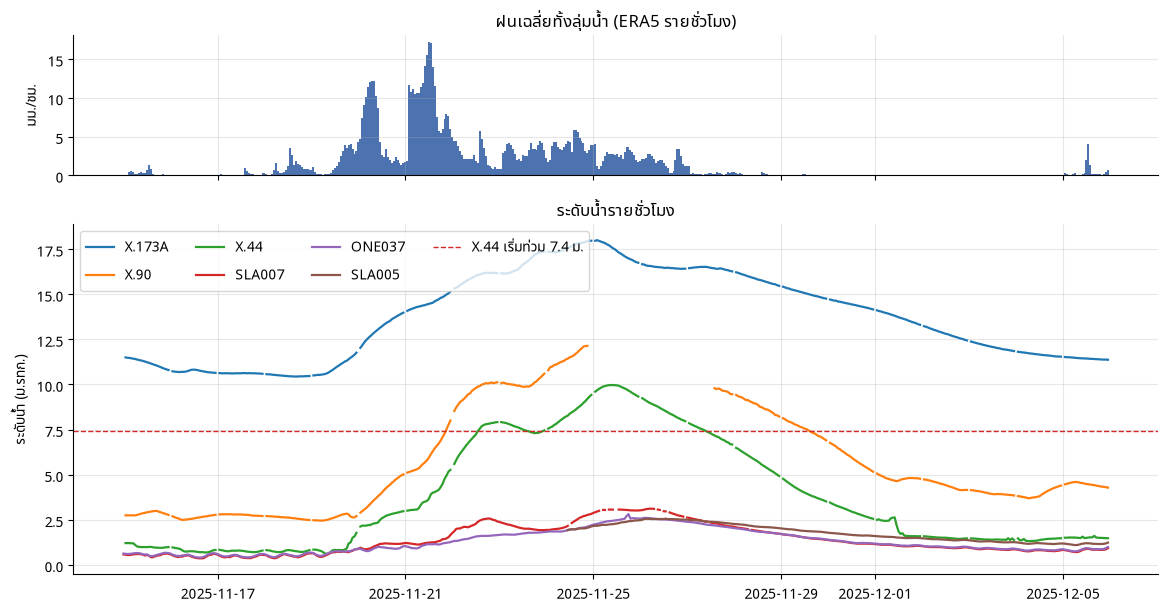

,ระดับสูงสุด,เวลา
station_code,,
X.173A,18.0,2025-11-25 02:00:00+07:00
X.90,12.18,2025-11-24 23:00:00+07:00
X.44,9.97,2025-11-25 10:00:00+07:00
SLA007,3.11,2025-11-26 05:00:00+07:00
ONE037,2.81,2025-11-25 18:00:00+07:00
SLA005,2.555,2025-11-26 13:00:00+07:00


In [5]:
start, end = "2025-11-15", "2025-12-05"
order = ["X.173A", "X.90", "X.44", "SLA007", "ONE037", "SLA005"]
window = level.loc[start:end, [c for c in order if c in level.columns]]

fig, (ax_rain, ax_level) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, height_ratios=[1, 2.5])

basin_rain = era5_basin["precipitation"].loc[start:end]
ax_rain.bar(basin_rain.index, basin_rain.values, width=1 / 24, color="#4c72b0")
ax_rain.set_ylabel("มม./ชม.")
ax_rain.set_title("ฝนเฉลี่ยทั้งลุ่มน้ำ (ERA5 รายชั่วโมง)")

for code in window.columns:
    ax_level.plot(window.index, window[code], lw=1.6, label=code)
ax_level.axhline(X44_FLOOD, color=EVENT_COLOR, ls="--", lw=1, label=f"X.44 เริ่มท่วม {X44_FLOOD} ม.")
ax_level.set_ylabel("ระดับน้ำ (ม.รทก.)")
ax_level.set_title("ระดับน้ำรายชั่วโมง")
ax_level.legend(ncol=4, loc="upper left")
plt.show()

peaks = window.agg(["max", "idxmax"]).T
peaks.columns = ["ระดับสูงสุด", "เวลา"]
peaks

In [6]:
event_rain = pandas.DataFrame({
    "ERA5 เฉลี่ยลุ่มน้ำ": era5_basin_daily["precipitation"],
    **{
        f"สถานี {code}": rain_gauge[rain_gauge["station_code"] == code].set_index("date")["rain_mm"]
        for code in ["48569", "SLA001", "MOU421"]
        if code in set(rain_gauge["station_code"])
    },
}).loc["2025-11-15":"2025-12-01"]
display(event_rain.round(1).T)
print("ฝนรวม 15 พ.ย.–1 ธ.ค. (มม.):")
print(event_rain.sum().round(0).to_string())

,2025-11-15,2025-11-16,2025-11-17,2025-11-18,2025-11-19,2025-11-20,2025-11-21,2025-11-22,2025-11-23,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28,2025-11-29,2025-11-30,2025-12-01
ERA5 เฉลี่ยลุ่มน้ำ,6.3,0.4,3.6,22.6,38.2,131.6,235.3,62.7,72.8,92.1,62.0,44.8,7.1,2.7,0.7,0.1,0.0
สถานี 48569,3.2,0.2,0.0,3.2,155.0,46.8,370.2,139.6,143.8,262.0,128.4,36.0,1.4,0.0,0.0,NaN,0.0
สถานี SLA001,6.4,3.6,1.0,2.0,129.0,51.2,266.0,95.2,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0
สถานี MOU421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ฝนรวม 15 พ.ย.–1 ธ.ค. (มม.):
ERA5 เฉลี่ยลุ่มน้ำ     783.0
สถานี 48569           1290.0
สถานี SLA001           554.0
สถานี MOU421             0.0


## 4 · เวลาเดินทางของน้ำ (travel time) จากต้นน้ำถึงตัวเมือง
หาทุกเหตุการณ์ที่ระดับน้ำ X.44 ขึ้นเป็นยอดเกิน 3 ม. แล้ววัดว่ายอดน้ำที่สถานีต้นน้ำมาถึงก่อน X.44 กี่ชั่วโมง
ช่วงเวลานี้คือ **lead time ที่แจ้งเตือนได้จากข้อมูลวัดจริงล้วนๆ** ถ้าต้องการเตือนล่วงหน้านานกว่านี้ต้องพึ่งฝนและพยากรณ์ฝน

In [7]:
x44_hourly = level["X.44"]
x44_daily_max = x44_hourly.resample("D").max()

events = []
for day in x44_daily_max[x44_daily_max > 3].index:
    around = x44_hourly[day - pandas.Timedelta("3D"):day + pandas.Timedelta("3D")]
    if around.idxmax().floor("D") != day:
        continue  # not the crest of this rise
    crest = around.idxmax()
    row = {"ยอดน้ำ X.44": crest, "ระดับ (ม.)": around.max()}
    for upstream in ["X.173A", "X.90", "SLA002"]:
        before = level[upstream][crest - pandas.Timedelta("48h"):crest]
        if before.notna().sum() >= 24:
            row[f"{upstream} มาก่อน (ชม.)"] = (crest - before.idxmax()).total_seconds() / 3600
    events.append(row)

crests = pandas.DataFrame(events).set_index("ยอดน้ำ X.44")
display(crests.round(2))
print("ค่ามัธยฐาน lead time (ชม.):")
print(crests.filter(like="มาก่อน").median().round(1).to_string())

,ระดับ (ม.),X.173A มาก่อน (ชม.),X.90 มาก่อน (ชม.),SLA002 มาก่อน (ชม.)
ยอดน้ำ X.44,,,,
2020-10-15 20:00:00+07:00,3.48,19.0,3.0,2.0
2020-11-25 05:00:00+07:00,3.40,28.0,4.0,6.0
2020-12-04 02:00:00+07:00,3.83,17.0,1.0,3.0
2020-12-18 07:00:00+07:00,3.41,0.0,0.0,0.0
2021-01-06 08:00:00+07:00,3.61,0.0,0.0,0.0
2021-11-29 15:00:00+07:00,3.08,0.0,0.0,0.0
2022-02-28 01:00:00+07:00,3.82,0.0,0.0,0.0
2022-05-11 19:00:00+07:00,3.42,25.0,4.0,4.0
2022-06-07 22:00:00+07:00,3.12,8.0,2.0,1.0


ค่ามัธยฐาน lead time (ชม.):
X.173A มาก่อน (ชม.)    6.5
X.90 มาก่อน (ชม.)      1.5
SLA002 มาก่อน (ชม.)    1.5


**ข้อควรระวัง:** ในเหตุการณ์ 2568 เซนเซอร์ X.173A ค้างที่ 18.00 ม. และ X.90 ขาดหายช่วงยอดน้ำ
ทำให้เวลาของยอดน้ำคลาดเคลื่อน ต้องจัดการค่าที่เกินช่วงวัดของเซนเซอร์ก่อนใช้เป็น feature

## 5 · ฝนจาก 3 แหล่งเทียบกัน
- **ERA5** (reanalysis 0.25°, จุดกริดเหนือตัวเมือง) — ยาว ต่อเนื่อง แต่เป็นค่าเฉลี่ยพื้นที่ ~28 กม.
- **GHCN-D 48569** (สถานีวัดจริง สนามบินหาดใหญ่) — ยาวที่สุดของสถานีจริง
- **ThaiWater** (โทรมาตรสถานีเดียวกัน) — ใช้ตอน real-time

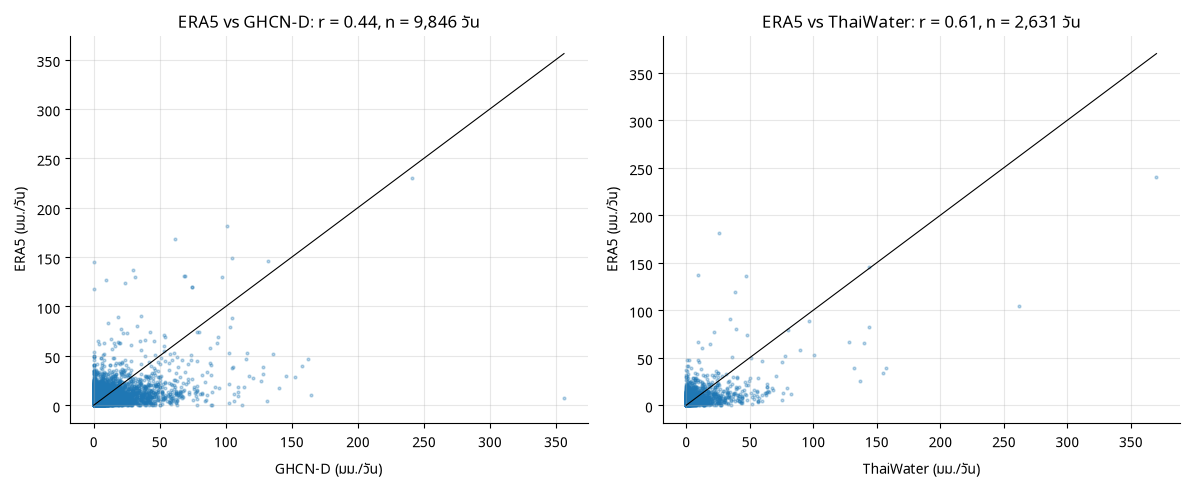

In [8]:
era5_city = era5[(era5["lat"] == 7.0) & (era5["lon"] == 100.5)].set_index("timestamp")["precipitation"]
era5_city = era5_city.resample("D").sum()
era5_city.index = era5_city.index.tz_localize(None)

ghcnd_hy = ghcnd[ghcnd["station_code"] == "48569"].set_index("date")["rain_mm"]
thaiwater_hy = rain_gauge[rain_gauge["station_code"] == "48569"].set_index("date")["rain_mm"]
rain_compare = pandas.DataFrame({"ERA5": era5_city, "GHCN-D": ghcnd_hy, "ThaiWater": thaiwater_hy})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, other in zip(axes, ["GHCN-D", "ThaiWater"]):
    pair = rain_compare[["ERA5", other]].dropna()
    ax.scatter(pair[other], pair["ERA5"], s=4, alpha=0.3)
    top = max(pair.max().max(), 1)
    ax.plot([0, top], [0, top], color="k", lw=0.8)
    ax.set_xlabel(f"{other} (มม./วัน)")
    ax.set_ylabel("ERA5 (มม./วัน)")
    ax.set_title(f"ERA5 vs {other}: r = {pair.corr().iloc[0, 1]:.2f}, n = {len(pair):,} วัน")
plt.tight_layout()
plt.show()

In [9]:
rows = []
for name, (event_start, event_end) in config.FLOOD_EVENTS.items():
    span = rain_compare.loc[event_start:event_end]
    rows.append({
        "เหตุการณ์": name,
        **{f"{col} รวม": span[col].sum(min_count=1) for col in span},
        **{f"{col} สูงสุด/วัน": span[col].max() for col in span},
    })
pandas.DataFrame(rows).set_index("เหตุการณ์").round(0)

,ERA5 รวม,GHCN-D รวม,ThaiWater รวม,ERA5 สูงสุด/วัน,GHCN-D สูงสุด/วัน,ThaiWater สูงสุด/วัน
เหตุการณ์,,,,,,
2000-11,467.0,239.0,NaN,183.0,102.0,NaN
2010-11,625.0,543.0,NaN,230.0,241.0,NaN
2025-11,840.0,NaN,1290.0,240.0,NaN,370.0


**ข้อสังเกต:** ERA5 จับเหตุการณ์ใหญ่ได้ทุกครั้ง แต่ค่าฝนรายวันที่สถานีจริงมักสูงกว่า (ERA5 เฉลี่ยพื้นที่กว้าง ทำให้ peak ถูกเกลี่ย)
จึงควรใช้ ERA5 เป็น feature ระยะยาว และ calibrate/ใช้คู่กับฝนสถานีจริงหรือฝนดาวเทียมความละเอียดสูงกว่า

## 6 · ฝนสะสม ความชื้นในดิน และระดับน้ำ X.44
ใช้ระดับน้ำ 06:00 รายวันของกรมชลฯ (มีตั้งแต่ 2560) จับคู่กับฝน ERA5 เฉลี่ยลุ่มน้ำสะสมย้อนหลัง N วัน
เพื่อดูว่าหน้าต่างฝนสะสมกี่วันอธิบายระดับน้ำได้ดีที่สุด

,Spearman กับระดับน้ำ X.44
soil_28_100,0.761
soil_0_7,0.635
rain_30d,0.620
rain_14d,0.558
rain_10d,0.523
rain_7d,0.482
rain_5d,0.437
rain_3d,0.356
rain_2d,0.303
rain_1d,0.249


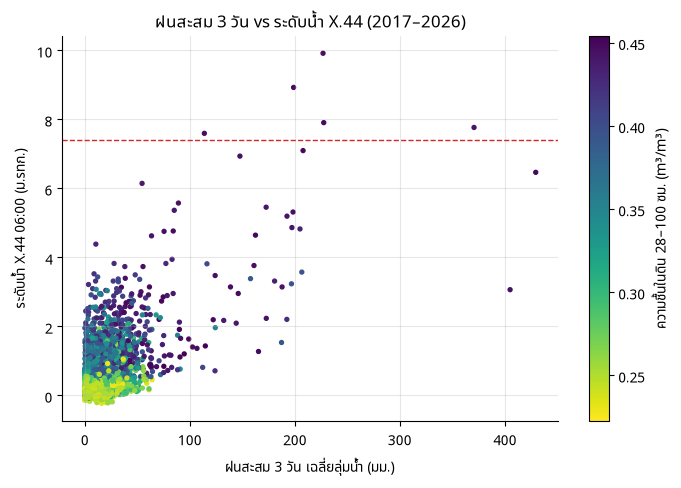

In [10]:
x44_daily = rid[rid["station_code"] == "X.44"].set_index("date")["waterlevel_msl"]
features = pandas.DataFrame({"x44": x44_daily})
for days in (1, 2, 3, 5, 7, 10, 14, 30):
    features[f"rain_{days}d"] = era5_basin_daily["precipitation"].rolling(days).sum()
features["soil_0_7"] = era5_basin_daily["soil_moisture_0_to_7cm"]
features["soil_28_100"] = era5_basin_daily["soil_moisture_28_to_100cm"]
features = features.dropna()

correlation = features.corr(method="spearman")["x44"].drop("x44").sort_values(ascending=False)
display(correlation.round(3).to_frame("Spearman กับระดับน้ำ X.44"))

fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(features["rain_3d"], features["x44"], c=features["soil_28_100"], s=8, cmap="viridis_r")
ax.axhline(X44_FLOOD, color=EVENT_COLOR, ls="--", lw=1)
ax.set_xlabel("ฝนสะสม 3 วัน เฉลี่ยลุ่มน้ำ (มม.)")
ax.set_ylabel("ระดับน้ำ X.44 06:00 (ม.รทก.)")
fig.colorbar(points, label="ความชื้นในดิน 28–100 ซม. (m³/m³)")
ax.set_title(f"ฝนสะสม 3 วัน vs ระดับน้ำ X.44 ({features.index.min():%Y}–{features.index.max():%Y})")
plt.show()

## 7 · GloFAS เทียบกับปริมาณน้ำที่วัดจริงที่ X.44
GloFAS เป็นแบบจำลองระดับโลกที่มีพยากรณ์ล่วงหน้าให้ฟรี ถ้ารูปแบบตรงกับค่าจริงจะใช้เป็น feature ล่วงหน้าได้

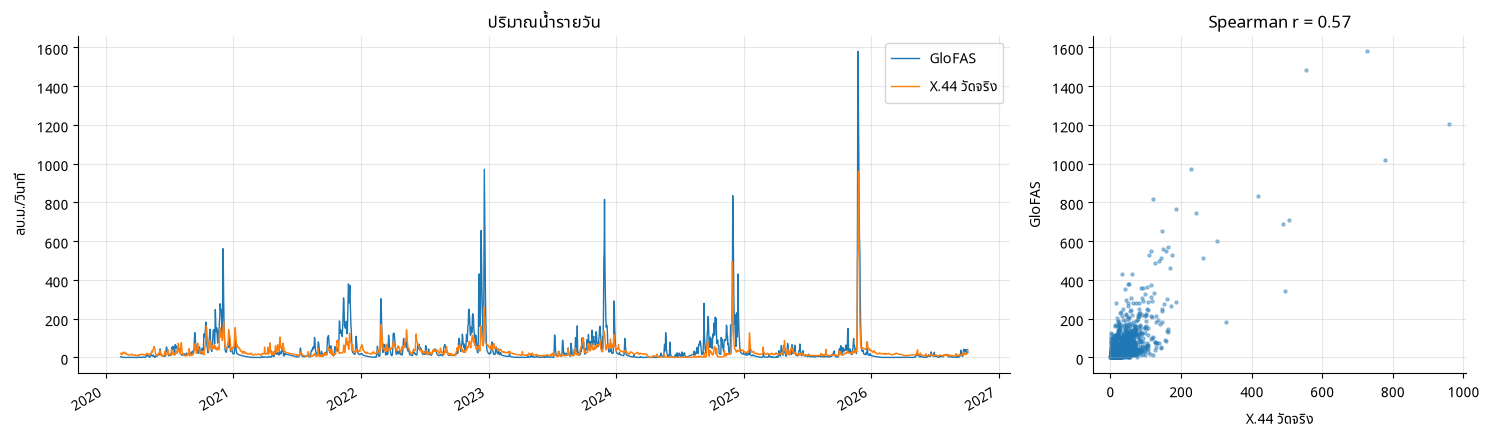

ชั่วโมงที่ X.44 สูงกว่า 7.4 ม. แต่ไม่มีค่าปริมาณน้ำ: 21% (ระดับน้ำเกิน rating curve จึงคำนวณปริมาณน้ำไม่ได้ — ช่วงน้ำท่วมจึงควรใช้ระดับน้ำเป็น target แทนปริมาณน้ำ)


,GloFAS ยอดน้ำ,GloFAS ลบ.ม./วิ,X.44 ยอดระดับน้ำ
2024-11,2024-11-30,834.6,2024-11-29
2025-11,2025-11-24,1580.25,2025-11-25


In [11]:
glofas_main = glofas[glofas["point"] == "utapao_main"].set_index("date")["river_discharge"]
observed = discharge["X.44"].resample("D").mean()
observed.index = observed.index.tz_localize(None)
# X.44 telemetry is continuous from 2020; the few earlier readings are left out
compare = pandas.DataFrame({"GloFAS": glofas_main, "X.44 วัดจริง": observed}).loc["2020":].dropna()

fig, (ax_ts, ax_sc) = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[2.5, 1])
compare.plot(ax=ax_ts, lw=1)
ax_ts.set_ylabel("ลบ.ม./วินาที")
ax_ts.set_title("ปริมาณน้ำรายวัน")
ax_sc.scatter(compare["X.44 วัดจริง"], compare["GloFAS"], s=5, alpha=0.4)
ax_sc.set_xlabel("X.44 วัดจริง")
ax_sc.set_ylabel("GloFAS")
ax_sc.set_title(f"Spearman r = {compare.corr(method='spearman').iloc[0, 1]:.2f}")
plt.tight_layout()
plt.show()

above_flood = level["X.44"] > X44_FLOOD
missing = discharge["X.44"][above_flood].isna().mean() * 100
print(f"ชั่วโมงที่ X.44 สูงกว่า {X44_FLOOD} ม. แต่ไม่มีค่าปริมาณน้ำ: {missing:.0f}% "
      "(ระดับน้ำเกิน rating curve จึงคำนวณปริมาณน้ำไม่ได้ — ช่วงน้ำท่วมจึงควรใช้ระดับน้ำเป็น target แทนปริมาณน้ำ)")

peak_compare = pandas.DataFrame({
    name: {
        "GloFAS ยอดน้ำ": glofas_main.loc[start:end].idxmax().date(),
        "GloFAS ลบ.ม./วิ": glofas_main.loc[start:end].max(),
        "X.44 ยอดระดับน้ำ": x44_daily_max.loc[start:end].idxmax().date(),
    }
    for name, (start, end) in {"2024-11": ("2024-11-15", "2024-12-15"), "2025-11": ("2025-11-15", "2025-12-05")}.items()
}).T
peak_compare

## 8 · ฤดูกาลและ ENSO

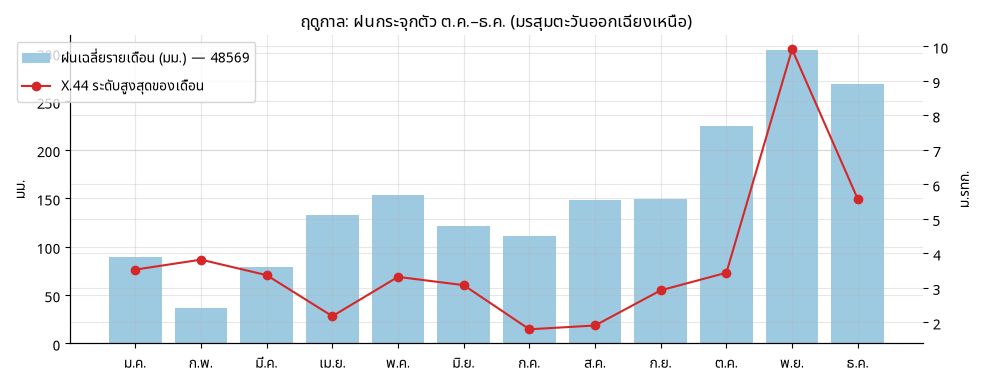

In [12]:
monthly_rain = ghcnd_hy.resample("MS").sum(min_count=20)
climatology = monthly_rain.groupby(monthly_rain.index.month).agg(["mean", "max"])
x44_monthly = x44_daily.groupby(x44_daily.index.month).agg(["mean", "max"])

fig, ax = plt.subplots(figsize=(11, 4))
months = numpy.arange(1, 13)
ax.bar(months, climatology["mean"], color="#9ecae1", label="ฝนเฉลี่ยรายเดือน (มม.) — 48569")
ax.set_xticks(months, ["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.", "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."])
ax.set_ylabel("มม.")
ax2 = ax.twinx()
ax2.plot(x44_monthly.index, x44_monthly["max"], color=EVENT_COLOR, marker="o", label="X.44 ระดับสูงสุดของเดือน")
ax2.set_ylabel("ม.รทก.")
ax.set_title("ฤดูกาล: ฝนกระจุกตัว ต.ค.–ธ.ค. (มรสุมตะวันออกเฉียงเหนือ)")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.88))
plt.show()

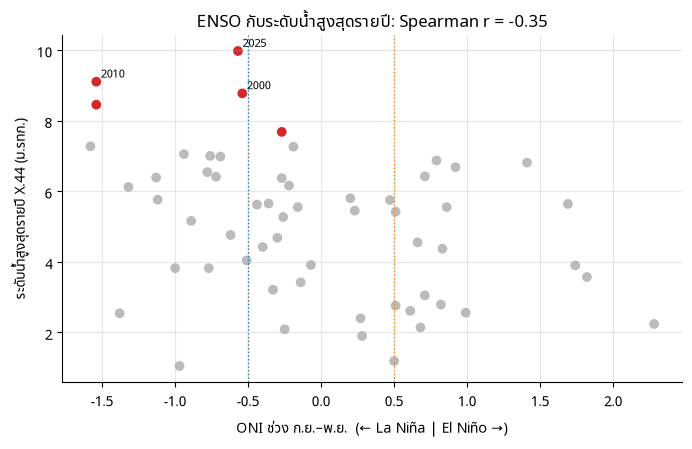

In [13]:
oni_son = oni[oni["season"] == "SON"].assign(year=lambda f: f["date"].dt.year).set_index("year")["oni"]
enso = annual.set_index("water_year").join(oni_son, how="inner")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(enso["oni"], enso["max_stage_msl"], color=["#bbbbbb" if v < X44_FLOOD else EVENT_COLOR for v in enso["max_stage_msl"]])
for year, row in enso[enso["max_stage_msl"] >= 8.5].iterrows():
    ax.annotate(str(year), (row["oni"], row["max_stage_msl"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.axvline(0.5, color="#ff7f0e", ls=":", lw=1)
ax.axvline(-0.5, color="#1f77b4", ls=":", lw=1)
ax.set_xlabel("ONI ช่วง ก.ย.–พ.ย.  (← La Niña | El Niño →)")
ax.set_ylabel("ระดับน้ำสูงสุดรายปี X.44 (ม.รทก.)")
ax.set_title(f"ENSO กับระดับน้ำสูงสุดรายปี: Spearman r = {enso.corr(method='spearman').iloc[0, 1]:.2f}")
plt.show()

## 9 · แผนที่น้ำท่วมจริง พ.ย. 2568 และภูมิประเทศ
มี label เชิงพื้นที่ 2 แหล่ง ทั้งคู่มาจาก Sentinel-1 แต่ใช้วิธีต่างกัน
- **Copernicus GFM** — จำแนกน้ำจากความสว่างของภาพเรดาร์ รวมทุกภาพในช่วง 23 พ.ย.–5 ธ.ค. เป็นขอบเขตท่วมสูงสุด
- **EOS-RS flood proxy** — change detection ภาพก่อน/หลังน้ำท่วม (ภาพ 23 พ.ย.)

ทั้งสองถูกแปลงลงกริดเดียวกับ DEM 30 ม. เพื่อเทียบกันและดูความสัมพันธ์กับความสูงภูมิประเทศ

In [14]:
import geopandas
from rasterio import features

dem = rioxarray.open_rasterio(RAW / "dem_glo30.tif").squeeze()
dem = dem.where(dem > -50)

# GFM: merge every scene onto the DEM grid (1 = flooded in any scene)
gfm_flooded = numpy.zeros(dem.shape, dtype=bool)
gfm_observed = numpy.zeros(dem.shape, dtype=bool)
for path in gfm_index["path"]:
    scene = rioxarray.open_rasterio(config.ROOT / path).squeeze()
    aligned = scene.rio.reproject_match(dem, nodata=255).values
    gfm_flooded |= aligned == 1
    gfm_observed |= aligned != 255

eosrs = geopandas.read_parquet(RAW / "eosrs_flood_2025.parquet")
eosrs_flooded = features.rasterize(
    eosrs.geometry, out_shape=dem.shape, transform=dem.rio.transform(), fill=0, default_value=1,
).astype(bool)

res_x, res_y = (abs(r) for r in dem.rio.resolution())
pixel_km2 = (res_x * 111.32 * numpy.cos(numpy.radians(7.0))) * (res_y * 110.57)

min_lon, min_lat, max_lon, max_lat = config.CITY_BBOX
lon_grid, lat_grid = numpy.meshgrid(dem.x.values, dem.y.values)
in_city = (lon_grid >= min_lon) & (lon_grid <= max_lon) & (lat_grid >= min_lat) & (lat_grid <= max_lat)

areas = pandas.DataFrame({
    area: {
        "GFM (ตร.กม.)": (gfm_flooded & mask).sum() * pixel_km2,
        "EOS-RS (ตร.กม.)": (eosrs_flooded & mask).sum() * pixel_km2,
        "ทั้งสองแหล่งตรงกัน (ตร.กม.)": (gfm_flooded & eosrs_flooded & mask).sum() * pixel_km2,
    }
    for area, mask in {"ตัวเมืองหาดใหญ่": in_city, "ทั้งลุ่มน้ำ": numpy.ones(dem.shape, dtype=bool)}.items()
}).T.round(1)
areas

,GFM (ตร.กม.),EOS-RS (ตร.กม.),ทั้งสองแหล่งตรงกัน (ตร.กม.)
ตัวเมืองหาดใหญ่,6.3,72.5,5.8
ทั้งลุ่มน้ำ,15.9,222.9,12.3


GFM เห็นพื้นที่ท่วมในตัวเมืองน้อยกว่า EOS-RS มาก เพราะเรดาร์สะท้อนกลับแรงจากผนังอาคาร (double bounce)
ทำให้น้ำท่วมระหว่างตึกไม่ดูเป็น "น้ำ" และ GFM ยังมี exclusion mask ตัดพื้นที่เมืองหนาแน่นออก
→ **ใช้ EOS-RS เป็น label หลักในเขตเมือง** และใช้ GFM เป็นข้อมูลเสริมนอกเมือง/ริมทะเลสาบ

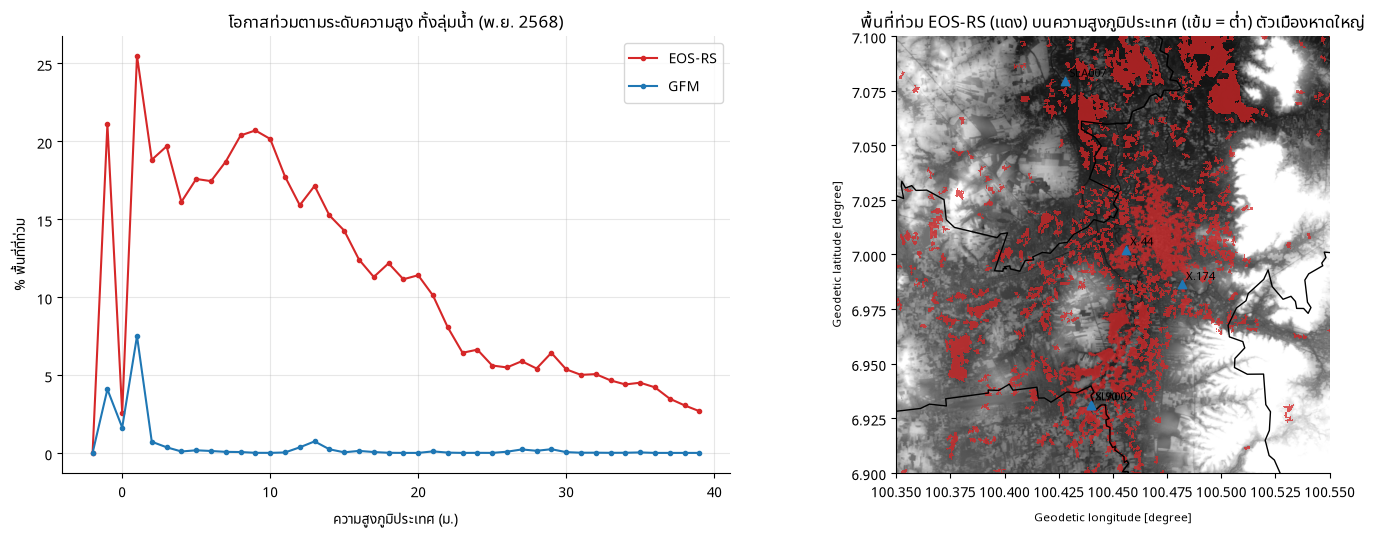

In [15]:
bins = numpy.arange(-2, 41, 1)
elevation = dem.values
valid = numpy.isfinite(elevation)

fig, (ax_rate, ax_map) = plt.subplots(1, 2, figsize=(15, 5.5), width_ratios=[1, 1.1])
for name, flooded, color in [("EOS-RS", eosrs_flooded, EVENT_COLOR), ("GFM", gfm_flooded & gfm_observed, "#1f77b4")]:
    wet, _ = numpy.histogram(elevation[valid & flooded], bins)
    total, _ = numpy.histogram(elevation[valid], bins)
    ax_rate.plot(bins[:-1], 100 * wet / numpy.maximum(total, 1), marker=".", color=color, label=name)
ax_rate.set_xlabel("ความสูงภูมิประเทศ (ม.)")
ax_rate.set_ylabel("% พื้นที่ที่ท่วม")
ax_rate.set_title("โอกาสท่วมตามระดับความสูง ทั้งลุ่มน้ำ (พ.ย. 2568)")
ax_rate.legend()

city_dem = dem.rio.clip_box(*config.CITY_BBOX)
ax_map.imshow(city_dem.values, cmap="Greys_r", vmin=-5, vmax=80,
              extent=[config.CITY_BBOX[0], config.CITY_BBOX[2], config.CITY_BBOX[1], config.CITY_BBOX[3]])
eosrs.clip(config.CITY_BBOX).plot(ax=ax_map, color=EVENT_COLOR, alpha=0.75, linewidth=0)
hatyai_gdf = geopandas.read_file(config.RESOURCES_DIR / "hatyai_boundary.geojson")
hatyai_gdf.boundary.plot(ax=ax_map, color="k", linewidth=1)
city_stations = stations[stations["kind"] == "waterlevel"]
ax_map.scatter(city_stations["lon"], city_stations["lat"], marker="^", color="#1f77b4", zorder=3)
for row in city_stations.itertuples():
    ax_map.annotate(row.code, (row.lon, row.lat), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax_map.set_xlim(config.CITY_BBOX[0], config.CITY_BBOX[2])
ax_map.set_ylim(config.CITY_BBOX[1], config.CITY_BBOX[3])
ax_map.set_title("พื้นที่ท่วม EOS-RS (แดง) บนความสูงภูมิประเทศ (เข้ม = ต่ำ) ตัวเมืองหาดใหญ่")
ax_map.grid(False)
plt.tight_layout()
plt.show()

/home/jk/mojito/.venv/lib/python3.13/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore



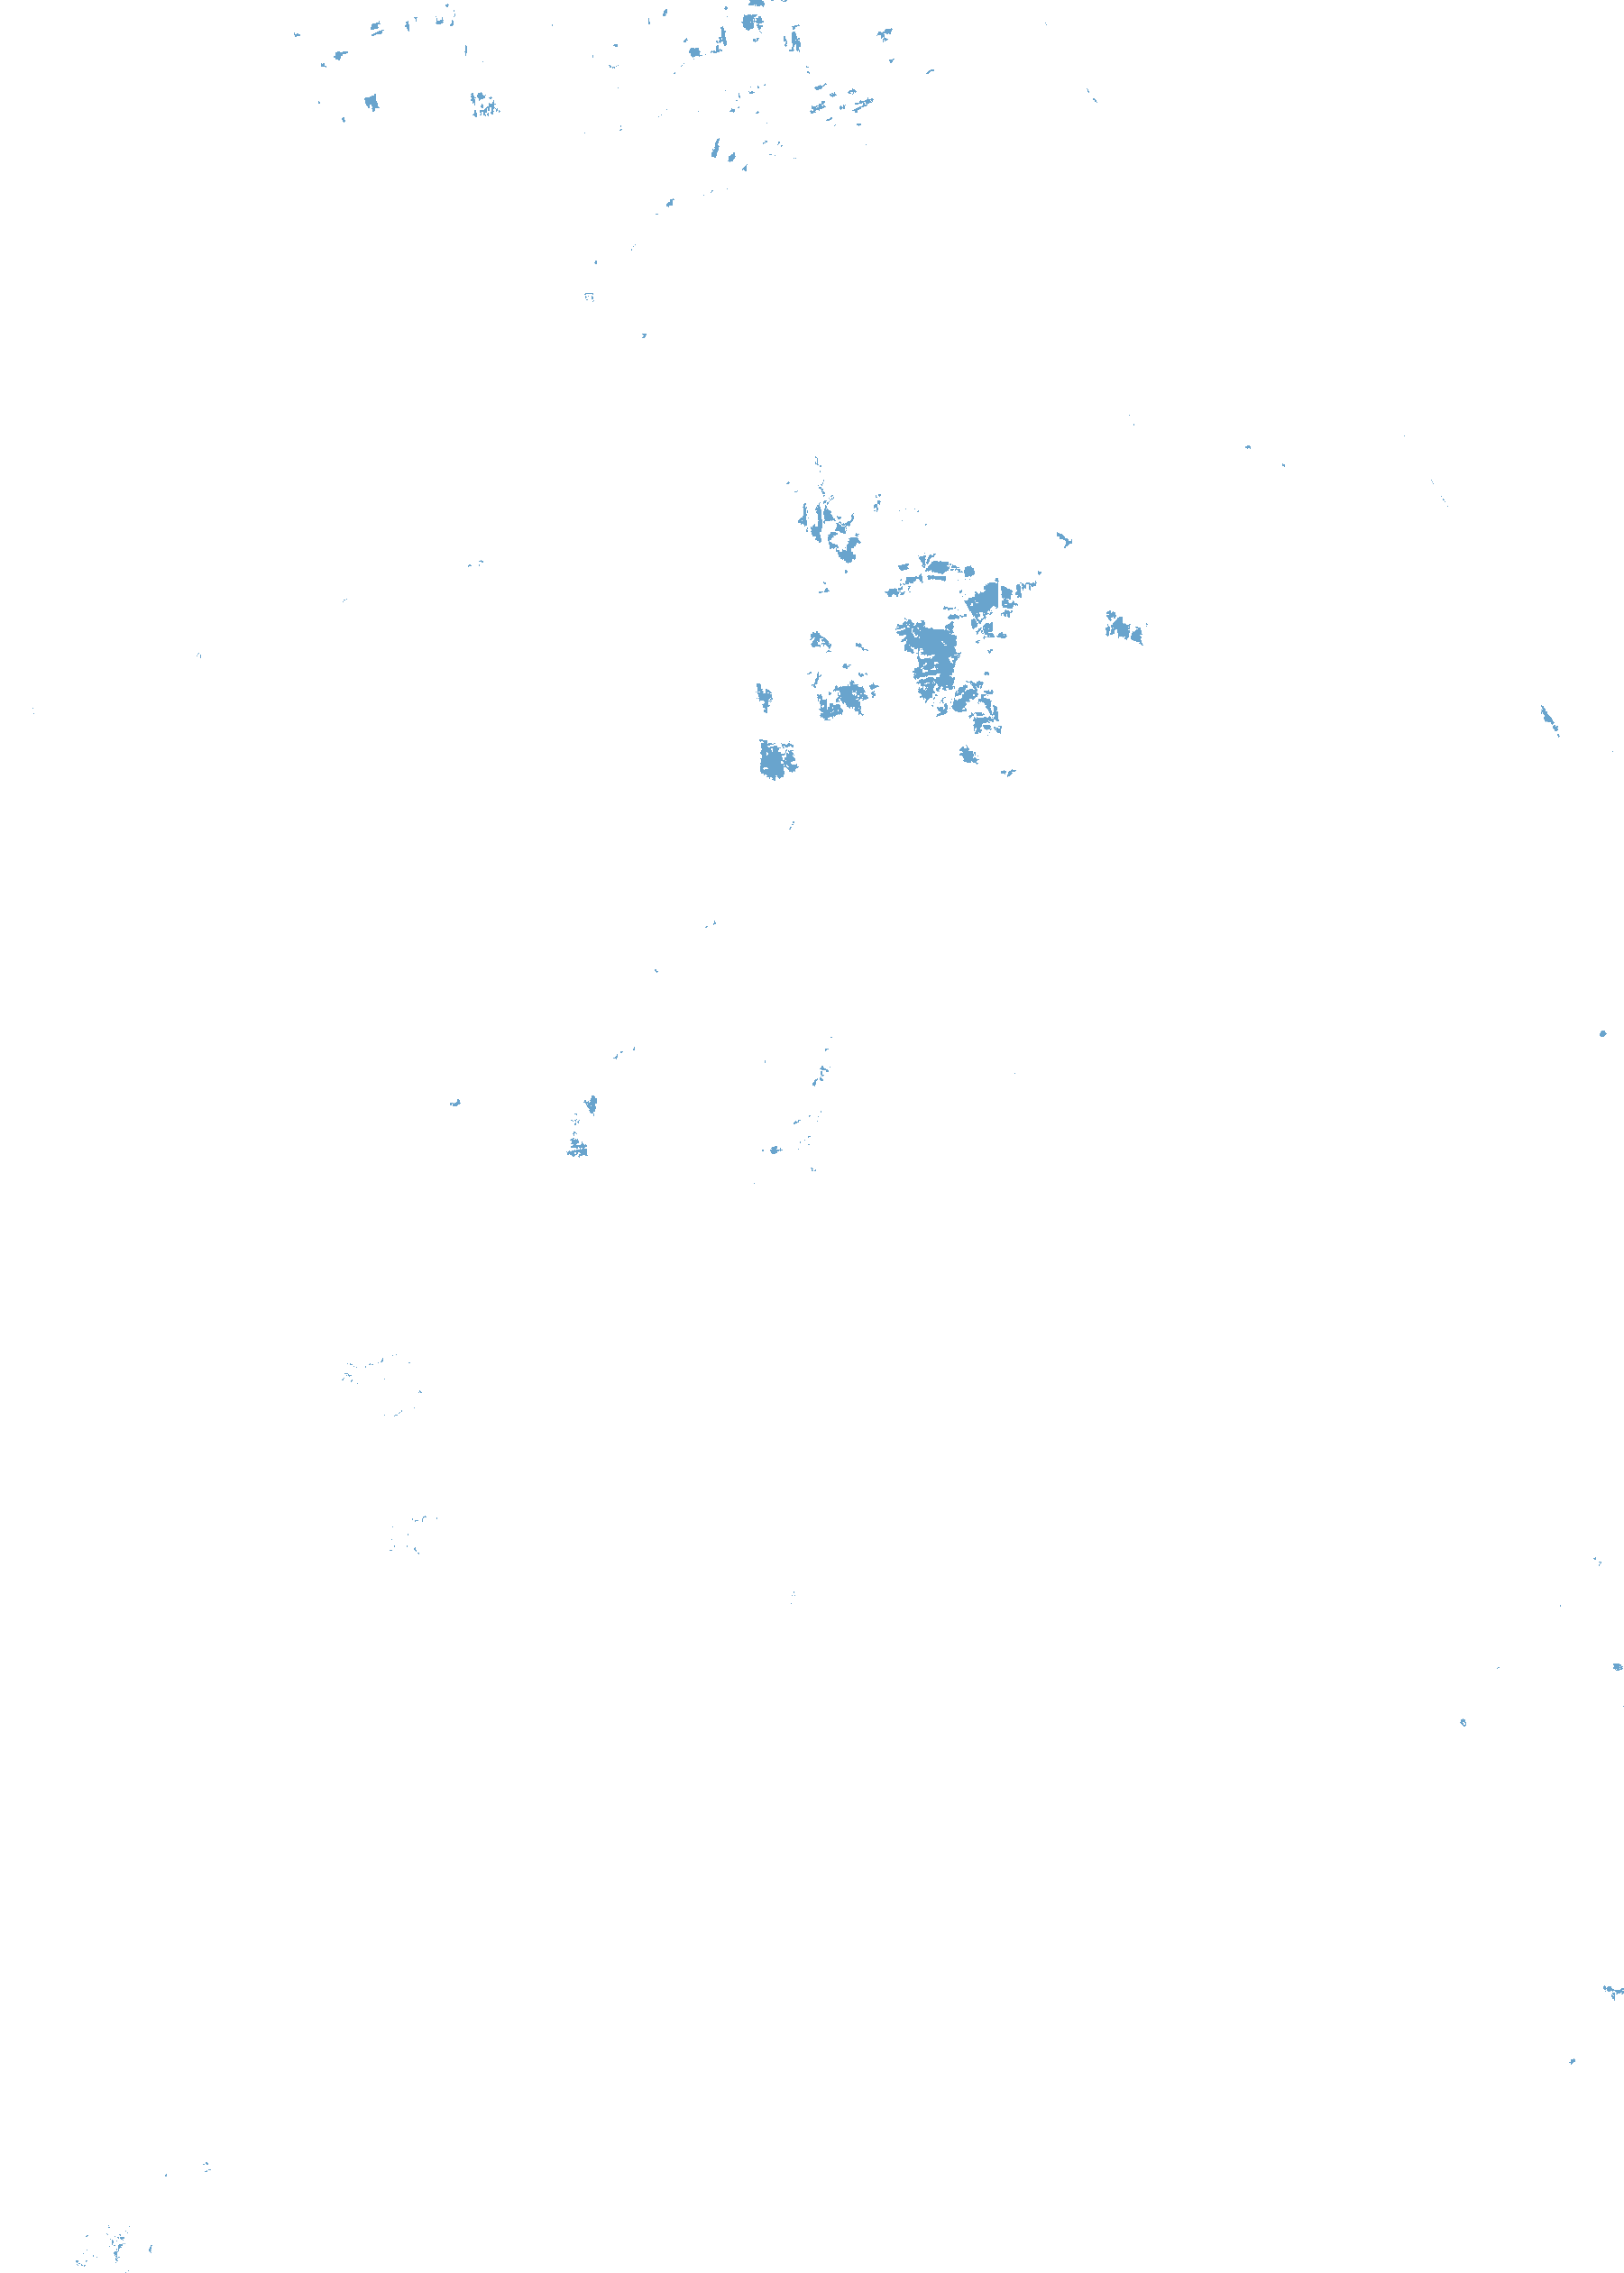

In [16]:
hatyai = json.loads((config.RESOURCES_DIR / "hatyai_boundary.geojson").read_text())

fmap = folium.Map(location=[7.0, 100.47], zoom_start=12, tiles="CartoDB positron")

west, south, east, north = dem.rio.bounds()
gfm_rgba = numpy.zeros((*dem.shape, 4), dtype="uint8")
gfm_rgba[gfm_flooded] = (31, 119, 180, 170)
folium.raster_layers.ImageOverlay(
    gfm_rgba, bounds=[[south, west], [north, east]], name="น้ำท่วม GFM (23 พ.ย.–5 ธ.ค.)", show=False,
).add_to(fmap)

folium.GeoJson(
    eosrs.simplify(0.0002).__geo_interface__, name="น้ำท่วม EOS-RS (23 พ.ย.)",
    style_function=lambda _: {"color": EVENT_COLOR, "weight": 0, "fillOpacity": 0.55},
).add_to(fmap)

folium.GeoJson(hatyai, name="เขตหาดใหญ่",
               style_function=lambda _: {"color": "#333", "weight": 1.5, "fillOpacity": 0}).add_to(fmap)

layer = {"waterlevel": folium.FeatureGroup("สถานีระดับน้ำ"), "rain": folium.FeatureGroup("สถานีวัดฝน")}
for row in stations.itertuples():
    folium.CircleMarker(
        [row.lat, row.lon], radius=6 if row.kind == "waterlevel" else 4,
        color="#1f77b4" if row.kind == "waterlevel" else "#2ca02c", fill=True, fill_opacity=0.9,
        tooltip=f"{row.code} · {row.name} ({row.agency})",
    ).add_to(layer[row.kind])
for group in layer.values():
    group.add_to(fmap)
folium.LayerControl().add_to(fmap)
fmap

## 10 · สรุปข้อค้นพบ และ feature ที่จะใช้ในโมเดล

### ข้อค้นพบ
| หัวข้อ | สิ่งที่พบ | ผลต่อการออกแบบโมเดล |
|---|---|---|
| ความครบถ้วน | ระดับน้ำรายชั่วโมงสถานีกรมชลฯ ใช้ได้จริงตั้งแต่ 2020, สถานี HII ตั้งแต่ 2012 แต่ขาดช่วง 2017–2018 | ชุดเทรนอนุกรมเวลาหลัก = 2020–ปัจจุบัน |
| คุณภาพ | SLA002 มีค่า sentinel 999999 กว่า 15,000 จุด, SLA005 กระโดดเกิน 1 ม./ชม. 414 ครั้ง, X.173A ค้างที่ 18.00 ม. ช่วงยอดน้ำ 2568 | ต้องกรอง sentinel / spike / ค่าเกินช่วงเซนเซอร์ก่อนสร้าง feature |
| เหตุการณ์หายาก | ใน 58 ปี X.44 เกิน 7.40 ม. แค่ 5 ปี (2531, 2543, 2548, 2553, 2568) และในช่วงข้อมูลรายชั่วโมงมีแค่ 2568 | ทำนายเป็น **ระดับน้ำ (regression)** แล้วแปลงเป็นระดับเตือนภัย ไม่ทำ classification ท่วม/ไม่ท่วมตรงๆ |
| เหตุการณ์ 2568 | ฝนลุ่มน้ำ (ERA5) ~780 มม. ใน 17 วัน, สถานีสนามบินหาดใหญ่ 1,290 มม. (370 มม. วันที่ 21 พ.ย.) X.44 ข้าม 7.40 ม. วันที่ 22 และถึงยอด 9.97 ม. วันที่ 25 พ.ย. | ยอดน้ำมาหลังฝนหนักสุด ~4 วัน → ฝนสะสมหลายวันเป็นตัวแปรสำคัญ |
| เวลาเดินทางของน้ำ | ยอดน้ำ X.173A มาก่อน X.44 ราว 6–25 ชม., X.90 ราว 1–11 ชม. | ข้อมูลวัดจริงอย่างเดียวเตือนล่วงหน้าได้ไม่ถึง 1 วัน → การทำนาย 5 วันต้องใช้ฝนสะสม ความชื้นในดิน และพยากรณ์ฝน |
| ตัวแปรที่สัมพันธ์กับระดับน้ำ | ความชื้นในดินชั้นลึก (Spearman 0.76) > ฝนสะสม 30 วัน (0.62) > ฝนสะสม 3 วัน (0.36) > ฝน 1 วัน (0.25) | สภาพ "อิ่มน้ำ" ของลุ่มน้ำสำคัญกว่าฝนวันเดียว |
| ฝน ERA5 vs สถานี | สหสัมพันธ์รายวัน 0.44–0.61, ERA5 ให้ยอดฝนต่ำกว่าสถานี (240 vs 370 มม.) | ใช้ ERA5 เป็น feature ระยะยาว + ฝนสถานีจริง, พิจารณา bias correction |
| GloFAS | เวลาของยอดน้ำตรงกับ X.44 (±1 วัน), Spearman 0.57 แต่ขนาดคลาดเคลื่อน | ใช้ GloFAS (และพยากรณ์ GloFAS) เป็น feature ล่วงหน้าได้ |
| ปริมาณน้ำวัดจริง | 21% ของชั่วโมงที่ X.44 > 7.40 ม. ไม่มีค่าปริมาณน้ำ (เกิน rating curve) | target ควรเป็นระดับน้ำ ไม่ใช่ปริมาณน้ำ |
| ENSO | ปีน้ำท่วมใหญ่ทั้งหมดอยู่ในช่วง La Niña / ค่าลบ (Spearman −0.35) | ใช้ ONI เป็น feature ระดับฤดูกาล |
| label เชิงพื้นที่ | GFM เห็นท่วมในตัวเมืองแค่ 6 ตร.กม. เทียบ EOS-RS 72 ตร.กม. (เรดาร์มองน้ำระหว่างอาคารไม่เห็น) EOS-RS เองก็มีพื้นที่ท่วมบนที่สูง 10–30 ม. ซึ่งน่าจะเป็น noise จากการเปลี่ยนแปลงพื้นที่เกษตร | ใช้ EOS-RS เป็น label หลักในเมือง กรอง noise ด้วย HAND/ความสูง และพิจารณาข้อมูลความเสียหายรายอาคาร (Microsoft) มาตรวจสอบ |

### ข้อเสนอสำหรับขั้นถัดไป
**โมเดลเวลา (ทำนายระดับน้ำ X.44 ล่วงหน้า 1–5 วัน)**
- target: ระดับน้ำสูงสุดรายวันของ X.44 วันที่ t+1 … t+5 → แปลงเป็นระดับเตือนภัย (ปกติ / ล้นตลิ่ง ≥ 7.15 ม. / ท่วมพื้นที่ลุ่ม ≥ 7.40 ม.)
- feature:
  - ระดับน้ำ X.44, X.90, X.173A, SLA005 (lag 0–72 ชม.)
  - ฝนสถานีและฝน ERA5 เฉลี่ยลุ่มน้ำ สะสม 1/3/7/14/30 วัน
  - ความชื้นในดิน 0–7 และ 28–100 ซม.
  - GloFAS discharge (และค่าพยากรณ์)
  - พยากรณ์ฝน t+1…t+5 (Open-Meteo)
  - เดือน, ONI
- baseline: LightGBM แยกโมเดลต่อ horizon → เทียบกับ LSTM

**โมเดลพื้นที่ (heatmap)**
- ความน่าจะเป็นที่แต่ละช่องกริด (H3 / 30 ม.) จะท่วม = f(ระดับน้ำ X.44 ที่ทำนายได้, ความสูง/HAND, ระยะห่างจากลำน้ำ, การใช้ที่ดิน)
- label: EOS-RS พ.ย. 2568 (+ GFM นอกเมือง), แบ่ง train/test ตามพื้นที่ (spatial split)